In [1]:
import numpy as np                                                                        
import matplotlib.pyplot as plt
import pyCloudy as pc
import pyneb as pn
from astropy    import constants as const
from astropy.io import ascii
import pandas as pd
from scipy import interpolate
import warnings
from scipy.integrate import quad, IntegrationWarning
import scipy.integrate as integrate
from numpy import log10, exp
import os
from astropy.constants import c
import astropy.units as u
from scipy import special
import matplotlib.gridspec as gridspec


from scipy.integrate import quad, IntegrationWarning
import scipy.integrate as integrate


from numpy import log10, exp
from DATA_CHECK import *

kpc = const.kpc.cgs.value

C_IV_K = 1548.187e-8  # cm
C_IV_H = 1550.772e-8  # cm

nu_Lya_K = c_cms / Ly_a_K
nu_Lya_H = c_cms / Ly_a_H

nu_CIV_K = c_cms / C_IV_K 
nu_CIV_H = c_cms / C_IV_H

Ryd_Lya_K = h_ev * nu_Lya_K / 13.6 
Ryd_Lya_H = h_ev * nu_Lya_H / 13.6 

Ryd_CIV_K = h_ev * nu_CIV_K / 13.6 
Ryd_CIV_H = h_ev * nu_CIV_H / 13.6 


nu_Lyman_limit = 13.6 / h_ev
print(f"{nu_Lyman_limit:.2e}")

3.29e+15


In [4]:
def Flux(Fc,F_max,lam,lam_c,sig_vel):
    del_lam = sig_vel / c_kms  * lam_c
    Flux = (F_max-Fc)*np.exp(- (lam-lam_c)**2 / del_lam**2) + Fc
    return Flux
def EW(Fc,F_max,lam_c,sig_vel):
    del_lam = sig_vel / c_kms  * lam_c
    EW =(F_max/ Fc)*np.sqrt(np.pi)*del_lam
    return EW

def Ryd_to_lam(Ryd_x):
    lambda_x = c_cms /  (Ryd_x * 13.6 /h_ev) *1e8

Lumin =44.0 # 37.0 - 44.0 + 41.5, 42.5, 43.5 and 44.5
idx_1 = 1 # 1 "" and  2 "no line transfer"
idx_2 = 2
metals = 0.1 # 0.001 - 10.0
Column_density_order = 20.5  # 18.0 - 25.0

cloudy_path_1 = CLOUDY_path(Lumin,idx_1,metals,Column_density_order)
cloudy_path_2 = CLOUDY_path(Lumin,idx_2,metals,Column_density_order)

Ryd, Fnu = QSO_SED(cloudy_path_1)
nu = (Ryd * 13.6 /h_ev)
nuFnu = Fnu * nu


normalized_factor = 10**(Lumin)/nuFnu[np.where(Ryd==1)[0]] 
normalized_Fnu = Fnu*normalized_factor
lambda_x = c_cms /  (Ryd * 13.6 /h_ev) *1e8
ii = np.where((lambda_x >1400) & (lambda_x <= 1700))[0]

aa = np.argmax(normalized_Fnu[ii])
F_max = normalized_Fnu[ii[aa]] 
lambda_c = lambda_x[ii[aa]]


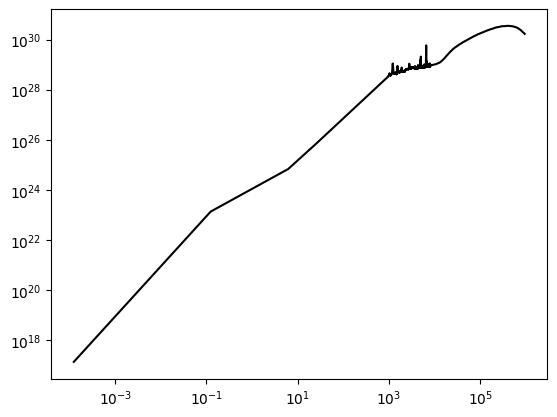

In [7]:
plt.plot(lambda_x,normalized_Fnu,'k-',alpha=1.0)
plt.yscale('log')
plt.xscale('log')